In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import make_interp_spline
from helper import compute_poi_ul

import json
# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

In [3]:

csv_path = './slepLR_xsecs.csv'
with open(csv_path, 'r') as f:
    lines = [l for l in f.readlines() if l.strip() and not l.startswith('#')]

data = np.genfromtxt(lines, delimiter=",", names=True, dtype=float)
mass = np.atleast_1d(np.asarray(data['mass'], dtype=float))
xsec = np.atleast_1d(np.asarray(data['xsec'], dtype=float))
order = np.argsort(mass)
mass = mass[order]
xsec = xsec[order]

nloXsecF = make_interp_spline(mass, xsec,k=2)


### Create dataframe with all results

In [4]:
# Load combined json file (created with collectData.py)
jsonFile = 'atlas_susy_2018_14_HeHe_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfRecast = pd.json_normalize(
    data,
    meta=columns
)

dfRecast['tau0_ns'] = (dfRecast['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfRecast['width_GeV'] = 6.582e-16/dfRecast['tau0_ns']

dfRecast['xsecNLO_slep_fb'] = nloXsecF(dfRecast['mLLP'])*1e3
dfRecast['kFactor'] = dfRecast['xsecNLO_slep_fb']/(dfRecast['Cross-Section (pb)']*1e3)

In [5]:
# Load combined json file (created with collectData.py)
jsonFile = 'atlas_susy_2018_14_ee_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfSlep = pd.json_normalize(
    data,
    meta=columns
)

dfSlep['tau0_ns'] = (dfSlep['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfSlep['width_GeV'] = 6.582e-16/dfSlep['tau0_ns']

dfSlep['xsecNLO_slep_fb'] = nloXsecF(dfSlep['mLLP'])*1e3
dfSlep['kFactor'] = dfSlep['xsecNLO_slep_fb']/(dfSlep['Cross-Section (pb)']*1e3)

## Plot Efficiencies and MC Uncertainties

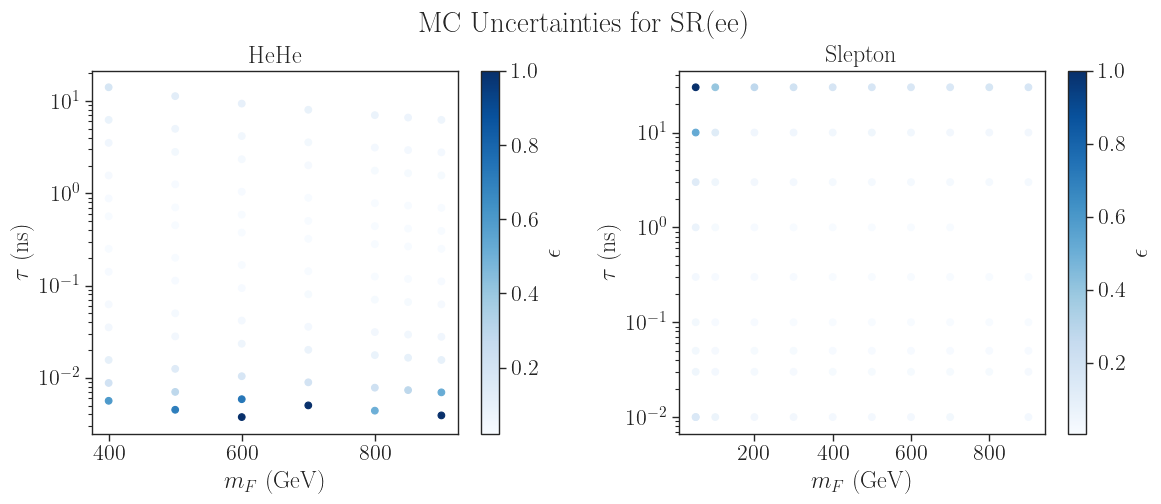

In [6]:
fig,axList =plt.subplots(figsize=(12,5),nrows=1,ncols=2)

title = r'$p p \to F F,\, F \to s + l$'
# Select only points with very light DM
xDMList_all = list((dfRecast['m5000022']/dfRecast['mLLP']).unique())
xDM  = min(xDMList_all)

dfs = [dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM], dfSlep]
titles = ['HeHe', 'Slepton']
for iax,ax in enumerate(axList):
    df = dfs[iax]
    x = df['mLLP']
    y = df['tau0_ns']
    tit_append = ''
    z = df['AccEffCuts_ee_err']/df['AccEffCuts_ee']

    im = ax.scatter(x,y,c=z,cmap='Blues')
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{F}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(titles[iax])

plt.tight_layout()
plt.suptitle('MC Uncertainties for SR(ee)', y=1.02)
plt.show()

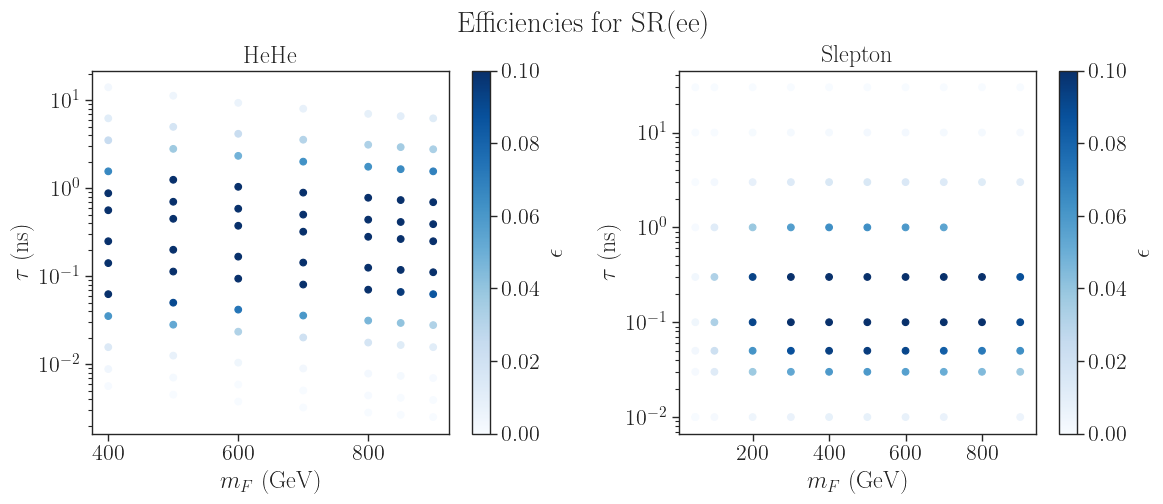

In [7]:
fig,axList =plt.subplots(figsize=(12,5),nrows=1,ncols=2)

title = r'$p p \to F F,\, F \to s + l$'
# Select only points with very light DM
xDMList_all = list((dfRecast['m5000022']/dfRecast['mLLP']).unique())
xDM  = min(xDMList_all)

dfs = [dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM], dfSlep]
titles = ['HeHe', 'Slepton']
for iax,ax in enumerate(axList):
    df = dfs[iax]
    x = df['mLLP']
    y = df['tau0_ns']
    if titles[iax] == 'HeHe':
        rescale_BR = 1./((1./3.)**2)  # Rescale by BR^2 for F->s+l (assuming 3 equal lepton flavors)
    else:
        rescale_BR = 1.0
    z = df['AccEffCuts_ee']*rescale_BR

    im = ax.scatter(x,y,c=z,cmap='Blues',vmin=0.,vmax=0.1)
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{F}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(titles[iax])

plt.tight_layout()
plt.suptitle('Efficiencies for SR(ee)', y=1.02)
plt.show()

## Compare efficiencies

,mLLP,tau0_ns,eff_hehe_interp,eff_slep_interp,ratio_hehe_over_slep
0,400.0,0.00563,0.000049,0.008121,0.054200
1,400.0,0.00879,0.000419,0.008121,0.464900
2,400.0,0.01560,0.001520,0.022428,0.610071
3,400.0,0.03520,0.006684,0.068289,0.880924
4,400.0,0.06250,0.012173,0.105087,1.042554
5,400.0,0.14100,0.018717,0.137972,1.220908
6,400.0,0.25000,0.019231,0.137812,1.255943
7,400.0,0.56300,0.016437,0.109898,1.346108
8,400.0,0.87900,0.012191,0.076447,1.435268
9,400.0,1.56000,0.007367,0.050039,1.325043


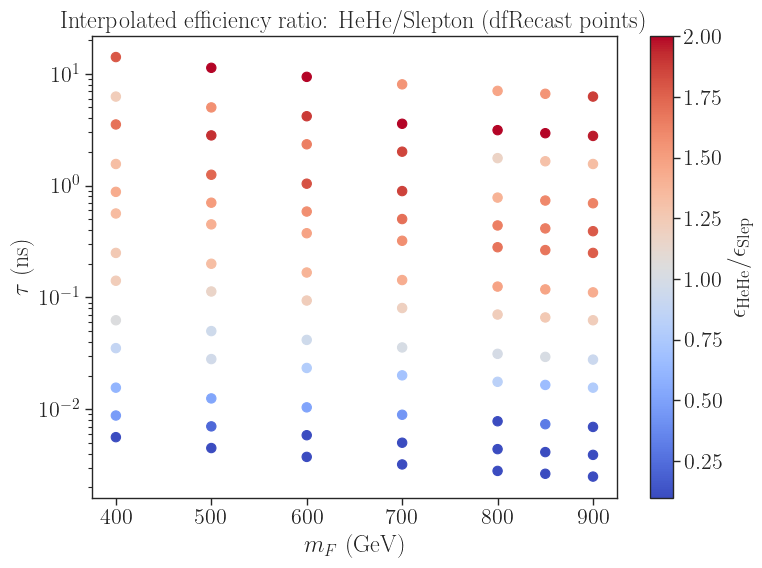

In [8]:
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

# Match the same kinematic slice used above for HeHe
xDM = min((dfRecast['m5000022'] / dfRecast['mLLP']).unique())
dfHeHe = dfRecast[dfRecast['m5000022'] / dfRecast['mLLP'] == xDM].copy()

# Keep only finite values
dfHeHe = dfHeHe[np.isfinite(dfHeHe['mLLP']) & np.isfinite(dfHeHe['tau0_ns']) & np.isfinite(dfHeHe['AccEffCuts_ee'])]
dfSlepClean = dfSlep[np.isfinite(dfSlep['mLLP']) & np.isfinite(dfSlep['tau0_ns']) & np.isfinite(dfSlep['AccEffCuts_ee'])].copy()

pts_hehe = np.column_stack([dfHeHe['mLLP'].to_numpy(dtype=float), dfHeHe['tau0_ns'].to_numpy(dtype=float)])
pts_slep = np.column_stack([dfSlepClean['mLLP'].to_numpy(dtype=float), dfSlepClean['tau0_ns'].to_numpy(dtype=float)])

eff_hehe = dfHeHe['AccEffCuts_ee'].to_numpy(dtype=float)
eff_slep = dfSlepClean['AccEffCuts_ee'].to_numpy(dtype=float)

# Interpolate Slepton efficiencies on the dfRecast points
interp_slep_lin = LinearNDInterpolator(pts_slep, eff_slep, fill_value=np.nan)
interp_slep_near = NearestNDInterpolator(pts_slep, eff_slep)

# Evaluate only at dfRecast points
m_common = pts_hehe[:, 0]
tau_common = pts_hehe[:, 1]
hehe_i = eff_hehe.copy()
slep_i = interp_slep_lin(m_common, tau_common)

mask_slep = ~np.isfinite(slep_i)
if np.any(mask_slep):
    slep_i[mask_slep] = interp_slep_near(m_common[mask_slep], tau_common[mask_slep])

rescale_BR = 1/((1./3.)**2)  # Rescale by BR^2 for F->s+l (assuming 3 equal lepton flavors)
ratio = np.divide(hehe_i*rescale_BR, slep_i, out=np.full_like(hehe_i, np.nan), where=slep_i > 0)

dfRatio = pd.DataFrame({
    'mLLP': m_common,
    'tau0_ns': tau_common,
    'eff_hehe_interp': hehe_i,
    'eff_slep_interp': slep_i,
    'ratio_hehe_over_slep': ratio
}).sort_values(['mLLP', 'tau0_ns']).reset_index(drop=True)

display(dfRatio.head(10))

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    dfRatio['mLLP'],
    dfRatio['tau0_ns'],
    c=dfRatio['ratio_hehe_over_slep'],
    cmap='coolwarm',
    vmin=0.1,
    vmax=2.0,
    s=45
    )
ax.set_yscale('log')
ax.set_xlabel(r'$m_F$ (GeV)')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_title(r'Interpolated efficiency ratio: HeHe/Slepton (dfRecast points)')
fig.colorbar(sc, ax=ax, label=r'$\epsilon_{\mathrm{HeHe}}/\epsilon_{\mathrm{Slep}}$')
plt.tight_layout()
plt.show()

In [9]:
tau0 = 0.098
tau1 = 0.01
y0 = 2.142e-8
y1 = np.sqrt(tau0*y0**2/tau1)
print(y1)

6.705520650926369e-08


In [10]:
6.58e-16/6.709663e-15

0.09806751844317667

In [11]:
9*9.2e-3/7.2e-2

1.1500000000000001

In [12]:
dfRatio[dfRatio['mLLP'] == 500.0]

,mLLP,tau0_ns,eff_hehe_interp,eff_slep_interp,ratio_hehe_over_slep
13,500.0,0.00450,0.000035,0.007910,0.039579
14,500.0,0.00703,0.000195,0.007910,0.222357
15,500.0,0.01250,0.000832,0.014343,0.522058
16,500.0,0.02810,0.005851,0.054482,0.966575
17,500.0,0.05000,0.010029,0.095300,0.947153
18,500.0,0.11300,0.017644,0.137012,1.159026
19,500.0,0.20000,0.020283,0.137418,1.328401
20,500.0,0.45000,0.019135,0.121967,1.411984
21,500.0,0.70300,0.016027,0.095120,1.516441
22,500.0,1.25000,0.011074,0.057517,1.732831


In [18]:
xDM = min((dfRecast['m5000022'] / dfRecast['mLLP']).unique())
dfHeHe = dfRecast[dfRecast['m5000022'] / dfRecast['mLLP'] == xDM].copy()
dfHeHe[dfHeHe['mLLP'] == 500.0][['mLLP','tau0_ns','AccEffCuts_ee', 'frblock_2']]

,mLLP,tau0_ns,AccEffCuts_ee,frblock_2
193,500.0,1.25000,0.011074,6.000000e-09
252,500.0,0.11300,0.017644,2.000000e-08
285,500.0,0.01250,0.000832,6.000000e-08
318,500.0,0.20000,0.020283,1.500000e-08
320,500.0,0.05000,0.010029,3.000000e-08
343,500.0,0.45000,0.019135,1.000000e-08
374,500.0,0.00703,0.000195,8.000000e-08
387,500.0,5.00000,0.001950,3.000000e-09
406,500.0,11.30000,0.000520,2.000000e-09
429,500.0,2.81000,0.004153,4.000000e-09


In [20]:
dfSlep[dfSlep['mLLP'] == 500.0][['mLLP','tau0_ns','AccEffCuts_ee']]

,mLLP,tau0_ns,AccEffCuts_ee
1,500.0,30.00,0.000261
2,500.0,0.10,0.136951
3,500.0,0.03,0.059371
8,500.0,0.01,0.007910
17,500.0,10.00,0.001997
48,500.0,1.00,0.063604
63,500.0,0.05,0.095300
68,500.0,0.30,0.137884
75,500.0,3.00,0.014908


In [24]:
interp_slep_lin(500.,0.0125)

array(0.0143429)